# Практика к занятию 5: кластеризация

**Что попробуем**:

1. Реализуем **K-means вручную** и сравним со стандартными реализациями.
2. Применим **GaussianMixture** из sklearn.
3. Построим графики по **методу локтя** для **коэффициента силуэта**.
4. Визуализируем результаты на наборах данных — **blobs**, **moons**, **circles**, **noise**.

https://scikit-learn.org/stable/modules/clustering.html

## 1. Установка библиотек и импорты

В этом блоке подключаем основные библиотеки (numpy, matplotlib, sklearn и др.).

In [1]:
import warnings

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from sklearn.base import clone
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.mixture import GaussianMixture

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

## 2. Реализация KMeans вручную

Ниже — простая реализация `KMeans`:
- случайная инициализация центроидов (с опцией фиксированного random_state),
- итерации до сходимости или достижения max_iter,
- возвращает центры и метки для точек,
- вычисляем инерцию (сумма квадратов расстояний до центров).

In [2]:
def f(arg1, arg2):
  return arg1 + arg2

f('4', '3')

'43'

In [3]:
# help(cdist) #(X, centers, metric='euclidean')

In [4]:
class ManualKMeans:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_centers_ = None
        self.inertia_ = None
        self.labels_ = None

    # sklearn-совместимые методы:
    def get_params(self, deep=True):
        """
        Возвращает параметры конструктора (нужно для sklearn.clone)
        """
        return {
            "n_clusters": self.n_clusters,
            "max_iter": self.max_iter,
            "tol": self.tol,
            "random_state": self.random_state
        }

    def set_params(self, **params):
        """
        Устанавливает параметры и возвращает self (как у sklearn)
        """
        allowed = {"n_clusters", "max_iter", "tol", "random_state"}
        for k, v in params.items():
            if k not in allowed:
                raise ValueError(f"Unknown parameter '{k}' for ManualKMeans")
            setattr(self, k, v)
        return self

    def _init_centers(self, X):
        """
        Начальная инициализация (случайная)
        """
        # X = np.asarray(X)
        n_samples = X.shape[0]
        if self.n_clusters > n_samples:
            raise ValueError("n_clusters is larger than number of samples")
        # случайная инициализация
        rng = np.random.RandomState(self.random_state)
        indices = rng.choice(n_samples, self.n_clusters, replace=False)
        return X[indices].astype(float)

    def fit(self, X, y=None):
        """
        Обучение модели
        """
        X = np.asarray(X)  # Преобразуем входные данные в numpy-массив
        centers = self._init_centers(X)  # Инициализация центров кластеров

        for i in range(int(self.max_iter)):  # Основной цикл итераций K-Means
            dists = cdist(X, centers, metric='euclidean')  # Вычисляем расстояния точек до центров
            labels = np.argmin(dists, axis=1)  # Назначаем каждой точке ближайший центр
            new_centers = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k) else centers[k]
                for k in range(self.n_clusters)
            ])  # Обновляем центры как среднее точек каждого кластера

            shift = np.linalg.norm(new_centers - centers)  # Считаем изменение центров
            centers = new_centers
            if shift <= float(self.tol):  # Проверяем условие сходимости
                break

        # Сохраняем результаты обучения
        self.cluster_centers_ = centers
        self.labels_ = labels
        self.inertia_ = float(np.sum((X - centers[labels]) ** 2))  # Сумма квадратов расстояний до центров
        return self


    def predict(self, X):
        if self.cluster_centers_ is None:
            raise ValueError("Model is not fitted yet. Call fit() before predict().")
        dists = cdist(np.asarray(X), self.cluster_centers_)
        return np.argmin(dists, axis=1)

    def fit_predict(self, X, y=None):
        self.fit(X)
        return self.labels_

Чем меньше `inertia_`, тем плотнее кластеры и лучше модель объясняет данные.

Но при слишком большом количестве кластеров `inertia_` всегда уменьшается, поэтому её нельзя использовать в одиночку для выбора k.

## 3. Генерация датасетов — несколько сценариев

Создадим 4 датасета:
- `blobs` — хорошо разделимые сферы,
- `moons` — два полукруга (неделинируемые KMeans),
- `circles` — концентрические окружности (подход для DBSCAN/GMM лучше),
- `hard_blobs` — с шумом и перекрытием.


In [5]:
# Синтетические примеры
rng = np.random.RandomState(42)
X_blobs, y_blobs = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=42)
X_moons, y_moons = make_moons(n_samples=400, noise=0.07, random_state=42)
X_circles, y_circles = make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=42)

# сложный случай: blobs + шум
X_hard, y_hard = make_blobs(n_samples=350, centers=3, cluster_std=[0.2, 0.8, 0.4], random_state=1)
noise = rng.uniform(low=-6, high=6, size=(50, 2))
X_hard = np.vstack([X_hard, noise])

In [6]:
X_blobs.shape, y_blobs.shape

((500, 2), (500,))

In [7]:
np.unique(y_circles)

array([0, 1])

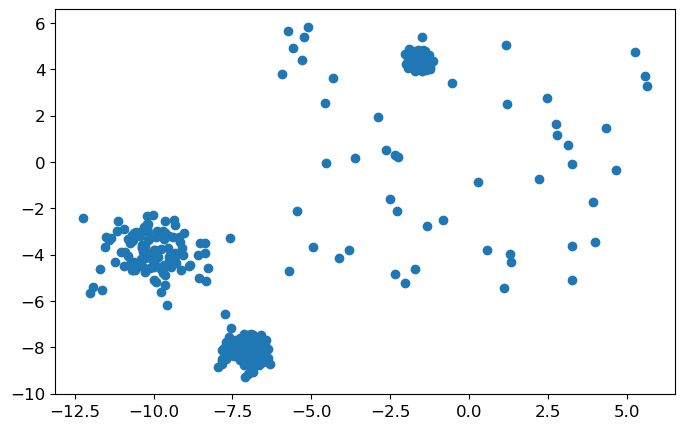

In [8]:
plt.scatter(X_hard[:, 0], X_hard[:, 1])

## 4. Утилитная функция: оценка модели кластеризации

Функция `evaluate_clusters` принимает модель и данные, перебирает количество кластеров и для каждого значения `k` вычисляет выбранную метрику — **коэффициент силуэта** или **инерцию**.

Результат визуализируется в виде графика зависимости метрики от числа кластеров, что помогает подобрать оптимальное `k`.

Функция универсальна и подходит для любых моделей, поддерживающих параметры `n_clusters` и методы `fit_predict()`.


In [9]:
def evaluate_clusters(
    model, X,
    k_range=range(2, 20),
    metric='silhouette'
):
    """
    Перебирает количество кластеров,
    обучает модель и строит график метрики.
    """
    scores = []
    for k in k_range:
        est = clone(model).set_params(n_clusters=k)
        labels = est.fit_predict(X)
        if len(np.unique(labels)) > 1:
            if metric == 'silhouette':
                score = silhouette_score(X, labels)
            else:
                score = np.nan
        else:
            score = np.nan
        scores.append(score)

    # help(est)
    plt.plot(k_range, scores, marker='o')
    plt.title(f'{metric.title()} vs Number of clusters')
    plt.xlabel('k')
    plt.ylabel(metric.title())
    plt.show()
    return scores

## 5. Примеры вызова функции для каждого датасета

Запустим сравнение моделей для всех четырёх синтетических наборов данных.


In [10]:
# help(KMeans)

In [11]:
# Подготовим классы моделей
models = {
    'ManualKMeans': lambda: ManualKMeans(random_state=42),
    'KMeans': lambda: KMeans(random_state=42, n_init=10),
    # 'GMM': lambda: GaussianMixture(random_state=42),
    'Agglomerative': lambda: AgglomerativeClustering(), #random_state=42),
    # 'DBSCAN': lambda: DBSCAN(eps=0.05)#random_state=42),
}

# Подготовим датасеты
datasets = {
    'blobs': X_blobs,
    'moons': X_moons,
    'circles': X_circles,
    'hard_blobs': X_hard
}

In [12]:
np.min(X_moons[0]), np.max(X_moons[0])

(np.float64(-0.027813291115354848), np.float64(0.41277309088484054))


>>> ManualKMeans


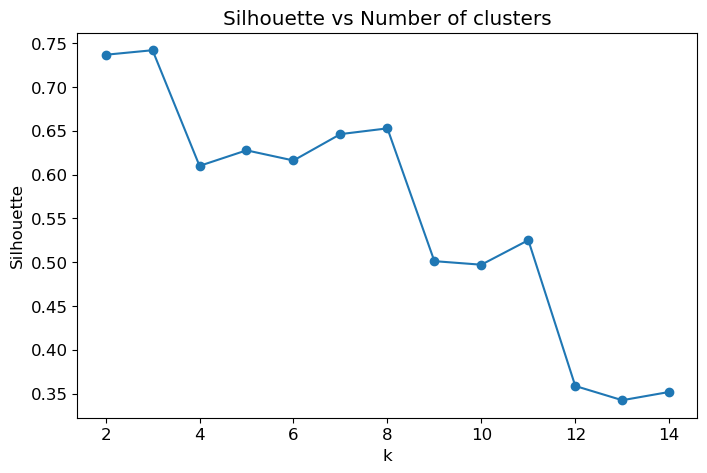

0.7418987903649065

>>> KMeans


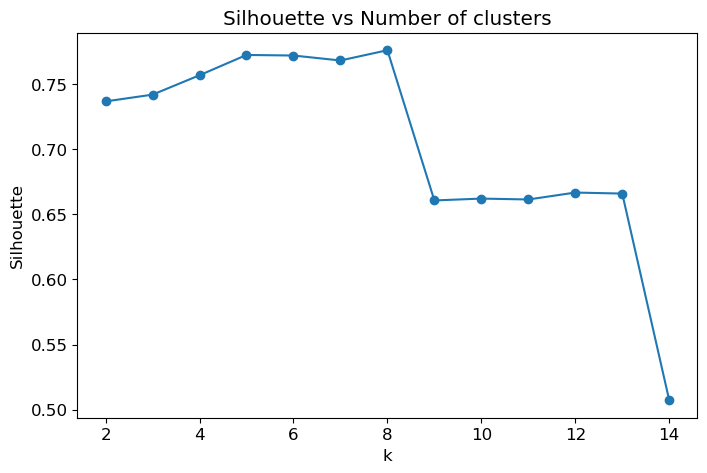

0.7759929011288034

>>> Agglomerative


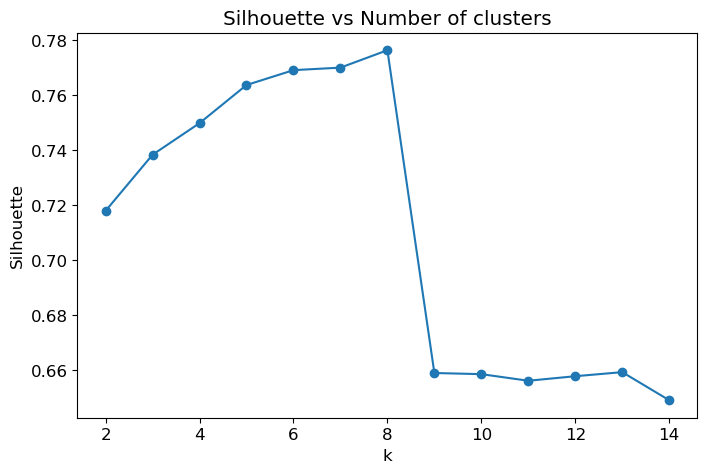

0.776419371963224


In [13]:
data_name = 'hard_blobs'
X = datasets[data_name]

for model_name, model_fn in models.items():
    print(f'\n>>> {model_name}')
    model = model_fn()
    # если модель поддерживает параметр n_clusters — ищем оптимальное k
    if 'n_clusters' in model.get_params().keys():
        scores = evaluate_clusters(model, X, k_range=range(2, 15), metric='silhouette')
        print(np.max(scores))
    else:
        # иначе просто строим модель без подбора k
        labels = model.fit_predict(X)
        if len(np.unique(labels)) > 1:
            score = silhouette_score(X, labels)
            print(f'Silhouette score = {score:.3f}')
        else:
            print('Кластеры не найдены (все точки в одном кластере)')

#### На заметку:

- KMeans хорошо работает на шарообразных, хорошо разделимых кластерах; плохо — на кольцах и «полумесяцах».
- GMM (Gaussian Mixture) полезен, когда кластеры имеют эллиптическую форму и перекрываются.
- ~DBSCAN хорошо выявляет кластеры произвольной формы и шум (отдельные точки), но чувствителен к параметрам `eps` и `min_samples`.~
- ~Agglomerative дает дендрограмму и может помогать выбрать число кластеров при наличии иерархической структуры.~